# Polling Systems: Simulation and Validation

This notebook analyzes the results produced by the polling-system simulator developed for **Project 3** of the Wireless Internet practical projects.

The notebook is intentionally an **analysis notebook**, not a second simulator. The simulation logic is kept in:

```text
src/
experiments/
```

This notebook only loads generated outputs, checks experiment completeness, validates simulation against theory, studies parameter sensitivity, analyzes the hot-station extension, and extracts report-ready tables.

## Source alignment

The notebook follows the project specification and the course model used for polling systems.

**Project requirements covered**

| Requirement | Covered in notebook |
|---|---|
| Discrete-event polling simulation | Results loaded from the simulator outputs |
| Multiple stations | Checked through experiment configurations |
| Poisson arrivals | Stated as model assumption |
| Configurable parameters | `M`, `rho`, `T`, `h`, `k`, discipline checked from CSVs |
| Exhaustive polling | Validated against theory and compared |
| Limited / round-robin polling | Validated against theory and compared |
| Average packet waiting time | Main performance metric |
| Simulation vs theory | Baseline and sweep validation |
| Varying traffic load and number of stations | `E[W]` vs `rho`, `E[W]` vs `M` |
| Hot-station extension | Per-station waiting time and fairness |

**Course model used**

Polling is treated as a scheduled multiple-access mechanism where stations access the channel cyclically. A polling message/token grants channel access, packet service time is denoted by `T`, token/switching time by `h`, and the service policy can be exhaustive, gated, or limited. This project implements exhaustive and limited polling.

## Notebook execution assumptions

Before running this notebook, the following scripts should already have been executed from the project root:

```powershell
python experiments/run_experiments.py
python experiments/analyze_results.py
python experiments/plot_results.py
python experiments/run_extension.py
python experiments/plot_extension.py
```

Expected inputs:

```text
outputs/tables/experiment_results.csv
outputs/tables/summary_results.csv
outputs/tables/extension_per_station.csv
outputs/tables/extension_fairness.csv
outputs/figures/*.png
```

## 1. Imports and paths

In [64]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 4)

In [65]:
def find_project_root() -> Path:
    # Find the project root from either the root folder or the notebooks/ folder.
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]
    for candidate in candidates:
        if (candidate / "outputs" / "tables").exists() and (candidate / "outputs" / "figures").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find project root. Run this notebook from the project root or from notebooks/."
    )

PROJECT_ROOT = find_project_root()
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
REPORT_READY_DIR = TABLES_DIR / "report_ready"
REPORT_READY_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Tables:       {TABLES_DIR}")
print(f"Figures:      {FIGURES_DIR}")

Project root: /home/garmar/wireless_project/project3-polling-systems
Tables:       /home/garmar/wireless_project/project3-polling-systems/outputs/tables
Figures:      /home/garmar/wireless_project/project3-polling-systems/outputs/figures


## 2. Load generated results

In [66]:
required_tables = {
    "experiment_results": TABLES_DIR / "experiment_results.csv",
    "summary_results": TABLES_DIR / "summary_results.csv",
    "extension_per_station": TABLES_DIR / "extension_per_station.csv",
    "extension_fairness": TABLES_DIR / "extension_fairness.csv",
}

missing_tables = [name for name, path in required_tables.items() if not path.exists()]
if missing_tables:
    raise FileNotFoundError(
        "Missing required tables: " + ", ".join(missing_tables) +
        "\nRun the experiment scripts before executing the notebook."
    )

experiment_results = pd.read_csv(required_tables["experiment_results"])
summary_results = pd.read_csv(required_tables["summary_results"])
extension_per_station = pd.read_csv(required_tables["extension_per_station"])
extension_fairness = pd.read_csv(required_tables["extension_fairness"])

print("Loaded tables:")
for name, path in required_tables.items():
    print(f"- {name}: {path}")

Loaded tables:
- experiment_results: /home/garmar/wireless_project/project3-polling-systems/outputs/tables/experiment_results.csv
- summary_results: /home/garmar/wireless_project/project3-polling-systems/outputs/tables/summary_results.csv
- extension_per_station: /home/garmar/wireless_project/project3-polling-systems/outputs/tables/extension_per_station.csv
- extension_fairness: /home/garmar/wireless_project/project3-polling-systems/outputs/tables/extension_fairness.csv


In [67]:
print("experiment_results:", experiment_results.shape)
print("summary_results:   ", summary_results.shape)
print("extension_per_station:", extension_per_station.shape)
print("extension_fairness:   ", extension_fairness.shape)

experiment_results: (252, 12)
summary_results:    (84, 14)
extension_per_station: (60, 6)
extension_fairness:    (6, 6)


## 3. Sanity checks

This section checks whether the generated result tables contain the expected disciplines, parameter values, seeds, and non-missing data.

In [68]:
print("Disciplines:", sorted(summary_results["discipline"].unique()))
print("M values:   ", sorted(summary_results["M"].unique()))
print("rho values: ", sorted(summary_results["rho"].unique()))
print("T values:   ", sorted(summary_results["T"].unique()))
print("h values:   ", sorted(summary_results["h"].unique()))
print("k values:   ", sorted(summary_results["k"].unique()))

Disciplines: ['exhaustive', 'limited']
M values:    [np.int64(5), np.int64(10), np.int64(20), np.int64(40), np.int64(80), np.int64(160)]
rho values:  [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7)]
T values:    [np.float64(3.0)]
h values:    [np.float64(0.8)]
k values:    [np.int64(1)]


In [69]:
configuration_overview = (
    summary_results[["discipline", "M", "rho", "T", "h", "k", "num_runs"]]
    .drop_duplicates()
    .sort_values(["discipline", "M", "rho"])
    .reset_index(drop=True)
)

configuration_overview.head(20)

,discipline,M,rho,T,h,k,num_runs
0,exhaustive,5,0.1,3.0,0.8,1,3
1,exhaustive,5,0.2,3.0,0.8,1,3
2,exhaustive,5,0.3,3.0,0.8,1,3
3,exhaustive,5,0.4,3.0,0.8,1,3
4,exhaustive,5,0.5,3.0,0.8,1,3
5,exhaustive,5,0.6,3.0,0.8,1,3
6,exhaustive,5,0.7,3.0,0.8,1,3
7,exhaustive,10,0.1,3.0,0.8,1,3
8,exhaustive,10,0.2,3.0,0.8,1,3
9,exhaustive,10,0.3,3.0,0.8,1,3


In [70]:
missing_values = pd.DataFrame({
    "experiment_results": experiment_results.isna().sum(),
    "summary_results": summary_results.isna().sum(),
}).fillna(0).astype(int)

missing_values[missing_values.sum(axis=1) > 0]

,experiment_results,summary_results


In [71]:
run_count_check = (
    summary_results.groupby(["discipline", "M", "rho"])["num_runs"]
    .first()
    .reset_index()
    .sort_values(["discipline", "M", "rho"])
)

run_count_check.head(20)

,discipline,M,rho,num_runs
0,exhaustive,5,0.1,3
1,exhaustive,5,0.2,3
2,exhaustive,5,0.3,3
3,exhaustive,5,0.4,3
4,exhaustive,5,0.5,3
5,exhaustive,5,0.6,3
6,exhaustive,5,0.7,3
7,exhaustive,10,0.1,3
8,exhaustive,10,0.2,3
9,exhaustive,10,0.3,3


**Sanity-check discussion.**

The expected structure is:

- two disciplines: `exhaustive` and `limited`;
- several values of `M` and `rho`;
- repeated runs per scenario through different random seeds;
- no missing values in the columns used for analysis.

This verifies that the notebook is analyzing a complete experimental campaign rather than isolated simulator outputs.

## 4. Simulation model

The simulator models a polling-based multiple-access system with local queues.

### Variables

| Symbol | Meaning |
|---|---|
| `M` | Number of stations |
| `i` | Station index, `i = 0, ..., M-1` |
| `Q_i` | Local queue of station `i` |
| `lambda_i` | Packet arrival rate at station `i` |
| `lambda` | Total packet arrival rate |
| `T` | Deterministic packet service/transmission time |
| `h` | Deterministic switching/token-passing time |
| `rho = lambda T` | Offered traffic load |
| `W` | Packet waiting time |

The measured waiting time is:

$$
W = t_{\text{service start}} - t_{\text{arrival}}.
$$

The notebook analyzes the empirical average:

$$
E[W] \approx \frac{1}{N}\sum_{p=1}^{N} W_p.
$$

### Assumptions

- Packet arrivals are Poisson.
- Stations have independent local queues.
- The polling server visits stations cyclically.
- Packet service time `T` is deterministic.
- Switching/token-passing time `h` is deterministic.
- Buffers are assumed infinite.
- A warm-up period is discarded before computing statistics.
- The operating point must satisfy the stability condition of the selected service discipline.

## 5. Polling disciplines and theoretical models

### Exhaustive polling

When a station receives the token, it transmits all packets currently in its queue and releases the token only when the queue becomes empty.

For the symmetric Poisson-arrival model used in the course, the waiting-time expression implemented in the project is:

$$
E[W]_{\text{exhaustive}}
=
\frac{\rho T}{2(1-\rho)}
+
\frac{(M-\rho)h}{2(1-\rho)}.
$$

Stability condition:

$$
\rho < 1.
$$

### Limited polling / round-robin

When a station receives the token, it can transmit at most `k` packets. In this project:

$$
k = 1,
$$

which corresponds to round-robin polling.

The waiting-time expression used for validation is:

$$
E[W]_{\text{limited}}
=
\frac{\rho(T+h)+Mh}{2\left(1-\rho\frac{T+h}{T}\right)}.
$$

Stability condition:

$$
\rho < \rho_{\max} = \frac{T}{T+h}.
$$

In [72]:
def stability_summary(df: pd.DataFrame) -> pd.DataFrame:
    out = df[["discipline", "M", "rho", "T", "h", "k"]].drop_duplicates().copy()
    out["rho_max"] = np.where(
        out["discipline"].eq("limited"),
        out["T"] / (out["T"] + out["h"]),
        1.0,
    )
    out["stable"] = out["rho"] < out["rho_max"]
    return out.sort_values(["discipline", "M", "rho"])

stab = stability_summary(summary_results)
stab.groupby("discipline").agg(
    min_rho=("rho", "min"),
    max_rho=("rho", "max"),
    min_rho_max=("rho_max", "min"),
    all_stable=("stable", "all"),
)

,min_rho,max_rho,min_rho_max,all_stable
discipline,,,,
exhaustive,0.1,0.7,1.0000,True
limited,0.1,0.7,0.7895,True


## 6. Experiment overview

The summary table aggregates repeated simulation runs. Each row corresponds to one scenario, defined by:

```text
discipline, M, rho, T, h, k
```

and contains the mean simulation result, theoretical result, and error metrics.

In [73]:
summary_results.head()

,discipline,M,rho,T,h,k,mean_simulation_EW,std_simulation_EW,mean_theoretical_EW,mean_absolute_error,mean_relative_error,max_relative_error,mean_num_packets,num_runs
0,exhaustive,5,0.1,3.0,0.8,1,2.3262,0.0247,2.3444,0.0251,0.0107,0.0144,3056.0000,3
1,exhaustive,5,0.2,3.0,0.8,1,2.7824,0.0085,2.7750,0.0074,0.0027,0.0061,6047.6667,3
2,exhaustive,5,0.3,3.0,0.8,1,3.3693,0.0139,3.3286,0.0408,0.0122,0.0156,9082.6667,3
3,exhaustive,5,0.4,3.0,0.8,1,4.1445,0.0406,4.0667,0.0778,0.0191,0.0294,12116.6667,3
4,exhaustive,5,0.5,3.0,0.8,1,5.1792,0.0205,5.1000,0.0792,0.0155,0.0196,15089.0000,3


In [74]:
summary_stats_by_discipline = (
    summary_results.groupby("discipline")
    .agg(
        scenarios=("rho", "size"),
        mean_simulated_waiting_time=("mean_simulation_EW", "mean"),
        mean_theoretical_waiting_time=("mean_theoretical_EW", "mean"),
        mean_relative_error_percent=("mean_relative_error", lambda x: 100 * x.mean()),
        max_relative_error_percent=("max_relative_error", lambda x: 100 * x.max()),
    )
    .reset_index()
)

summary_stats_by_discipline

,discipline,scenarios,mean_simulated_waiting_time,mean_theoretical_waiting_time,mean_relative_error_percent,max_relative_error_percent
0,exhaustive,42,41.1397,40.8574,1.0545,5.2657
1,limited,42,69.8121,68.7055,1.9724,15.0029


## 7. Baseline validation

The baseline validation uses the course-like scenario:

```text
M = 10
T = 3 ms
h = 0.8 ms
rho = 0.7
```

Both exhaustive and limited polling are compared against the corresponding theoretical waiting time.

In [75]:
def select_baseline(df: pd.DataFrame, target_M: int = 10, target_rho: float = 0.7) -> pd.DataFrame:
    mask = (df["M"] == target_M) & np.isclose(df["rho"], target_rho)
    baseline = df.loc[mask].copy()
    if baseline.empty:
        # Fallback: closest rho for the target M.
        candidates = df.loc[df["M"] == target_M].copy()
        if candidates.empty:
            raise ValueError(f"No rows found for M={target_M}.")
        closest_rho = candidates.iloc[(candidates["rho"] - target_rho).abs().argsort()[:1]]["rho"].iloc[0]
        baseline = candidates.loc[np.isclose(candidates["rho"], closest_rho)].copy()
        print(f"No exact baseline found for rho={target_rho}. Using closest rho={closest_rho}.")
    return baseline

baseline = select_baseline(summary_results)

baseline_table = baseline[[
    "discipline",
    "M",
    "rho",
    "T",
    "h",
    "k",
    "mean_simulation_EW",
    "mean_theoretical_EW",
    "mean_absolute_error",
    "mean_relative_error",
    "max_relative_error",
    "mean_num_packets",
    "num_runs",
]].copy()

baseline_table["mean_relative_error_percent"] = 100 * baseline_table["mean_relative_error"]
baseline_table["max_relative_error_percent"] = 100 * baseline_table["max_relative_error"]

baseline_table.sort_values("discipline")

,discipline,M,rho,T,h,k,mean_simulation_EW,mean_theoretical_EW,mean_absolute_error,mean_relative_error,max_relative_error,mean_num_packets,num_runs,mean_relative_error_percent,max_relative_error_percent
13,exhaustive,10,0.7,3.0,0.8,1,16.1844,15.9000,0.3772,0.0237,0.0527,21067.3333,3,2.3726,5.2657
55,limited,10,0.7,3.0,0.8,1,48.5980,47.0294,1.9874,0.0423,0.1134,21062.0000,3,4.2258,11.3415


**Baseline discussion.**

The baseline table should show that simulation and theory are close for both polling disciplines. Small discrepancies are expected because the simulator uses random arrivals and a finite simulation time. Increasing the number of seeds or the simulation duration reduces the residual error.

## 8. Helper for displaying generated figures

In [76]:
def display_figure(filename: str, title: str | None = None) -> None:
    path = FIGURES_DIR / filename
    if title:
        display(Markdown(f"### {title}"))
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f"**Missing figure:** `{path}`"))

## 9. Waiting time versus traffic load

This section studies how average waiting time changes with traffic load `rho`.

### Exhaustive polling: waiting time vs traffic load

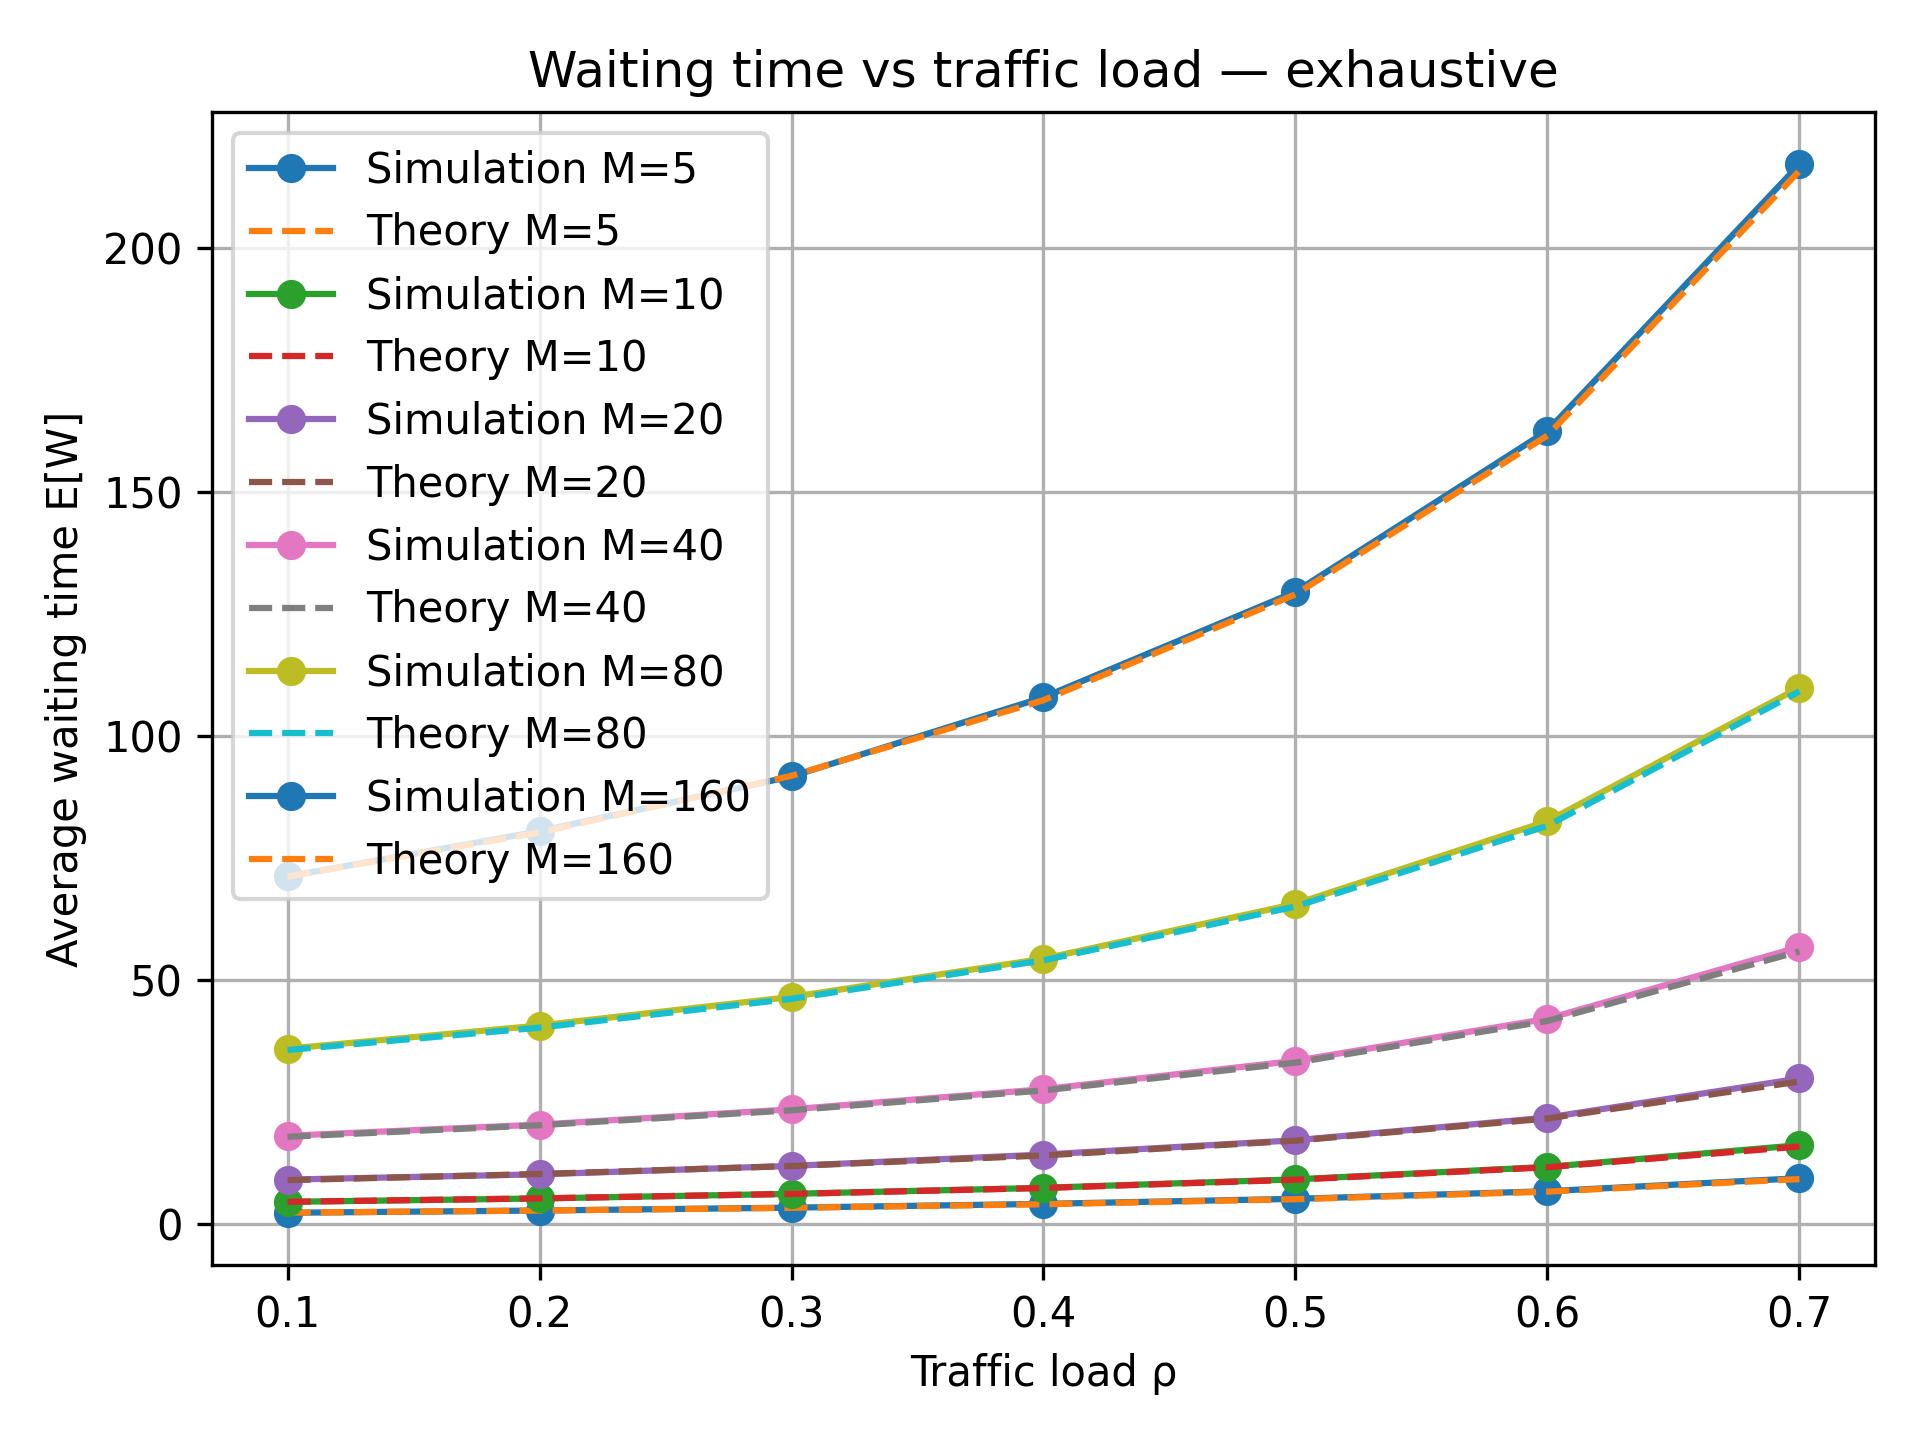

### Limited polling: waiting time vs traffic load

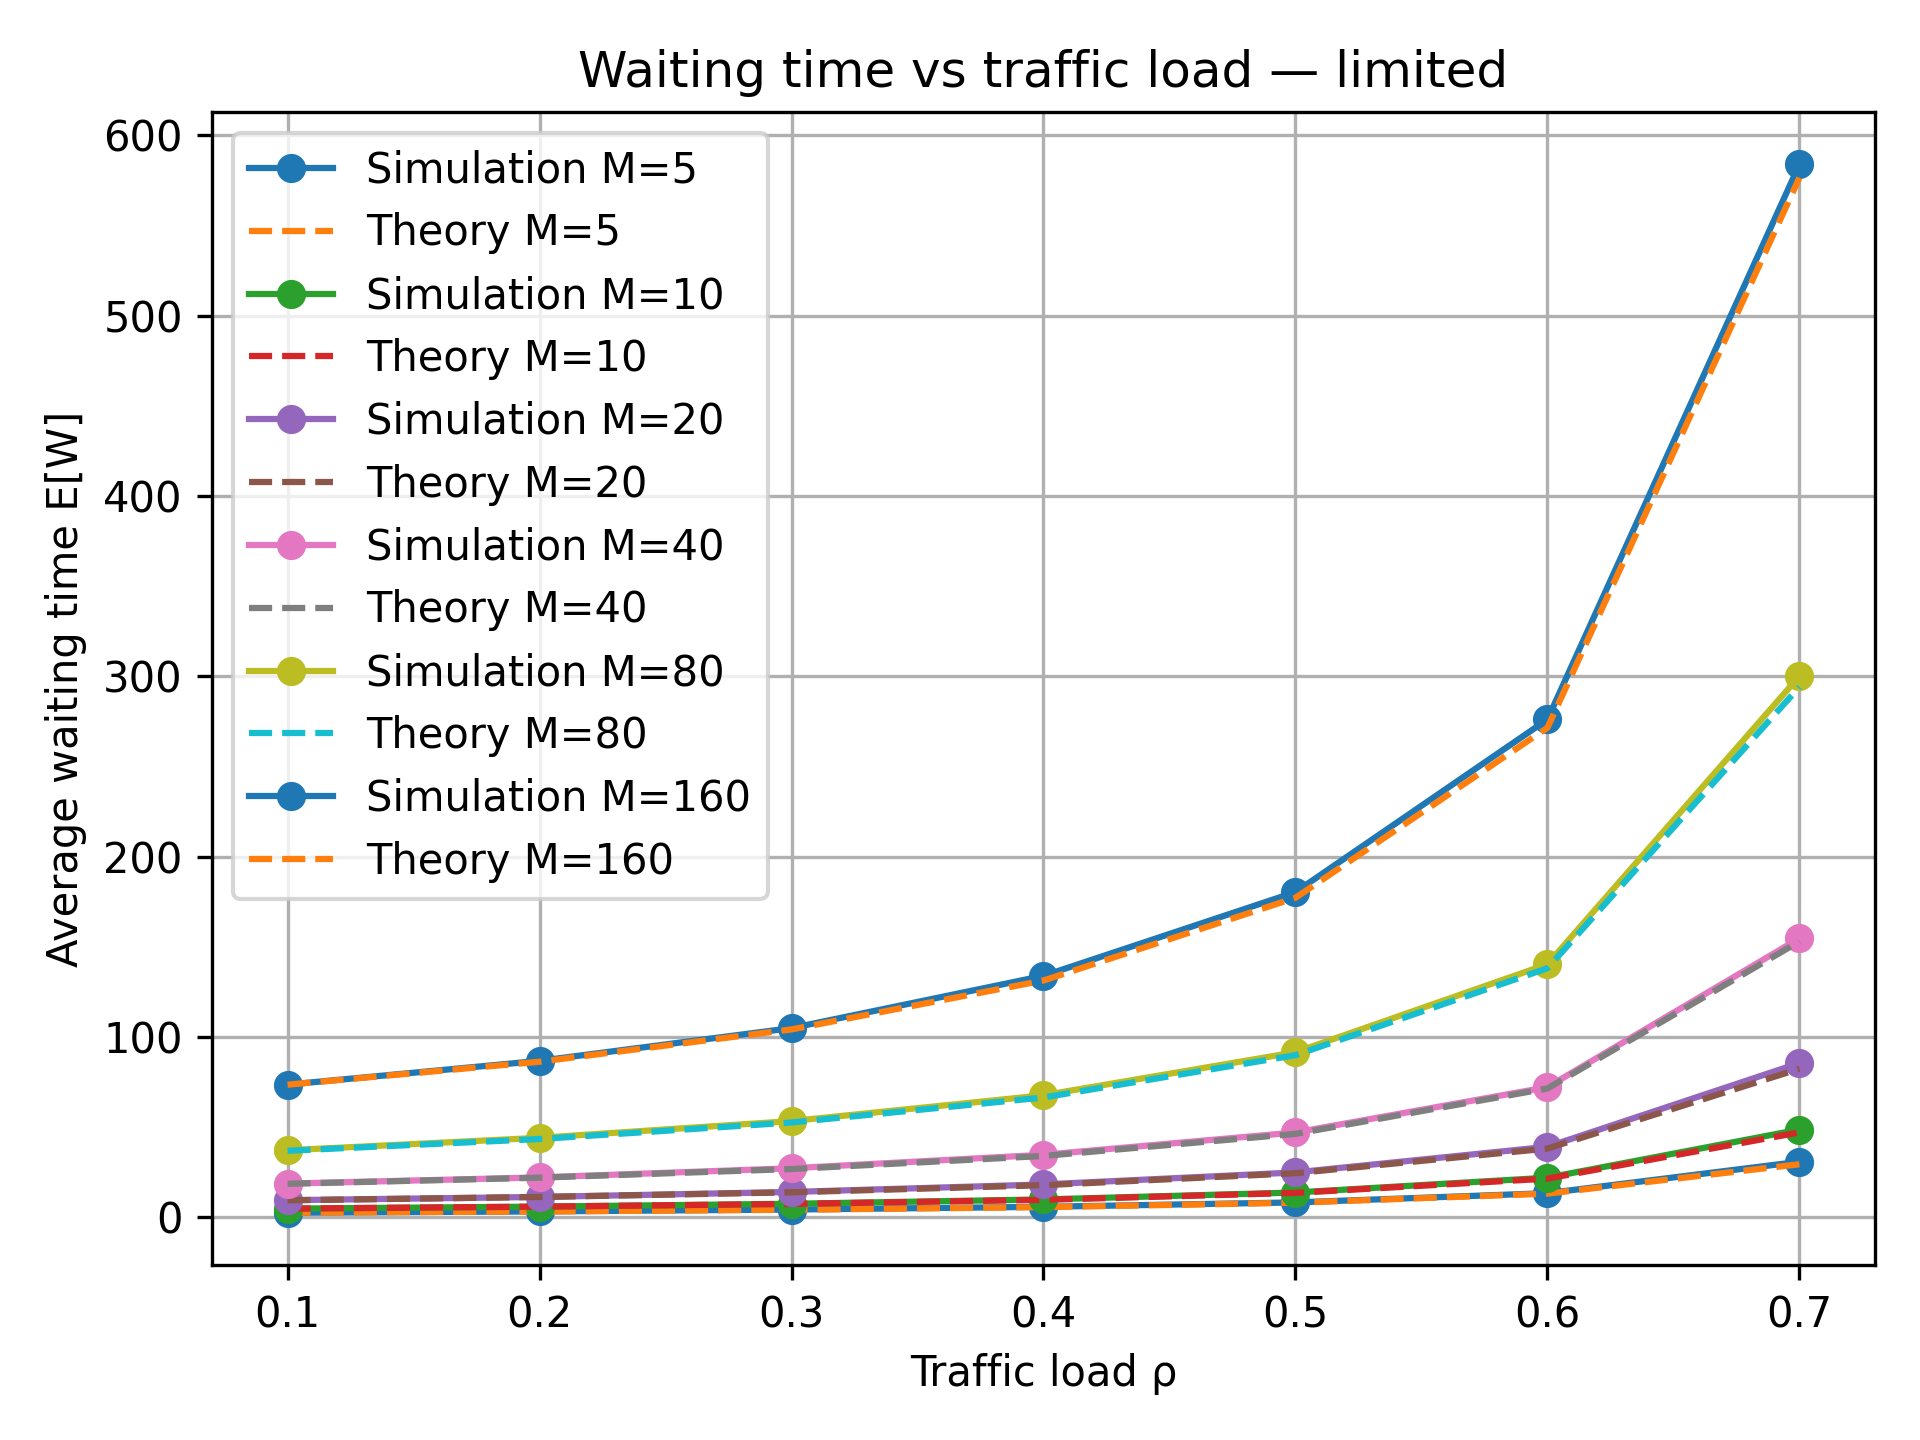

In [77]:
display_figure("waiting_time_vs_rho_exhaustive.png", "Exhaustive polling: waiting time vs traffic load")
display_figure("waiting_time_vs_rho_limited.png", "Limited polling: waiting time vs traffic load")

In [78]:
rho_table = (
    summary_results.groupby(["discipline", "rho"])
    .agg(
        mean_simulation_EW=("mean_simulation_EW", "mean"),
        mean_theoretical_EW=("mean_theoretical_EW", "mean"),
        mean_relative_error_percent=("mean_relative_error", lambda x: 100 * x.mean()),
    )
    .reset_index()
    .sort_values(["discipline", "rho"])
)

rho_table

,discipline,rho,mean_simulation_EW,mean_theoretical_EW,mean_relative_error_percent
0,exhaustive,0.1,23.5546,23.4556,0.8260
1,exhaustive,0.2,26.6476,26.5250,0.7502
2,exhaustive,0.3,30.5641,30.4714,0.8222
3,exhaustive,0.4,35.9796,35.7333,0.9722
4,exhaustive,0.5,43.3787,43.1000,0.9767
5,exhaustive,0.6,54.6079,54.1500,1.0781
6,exhaustive,0.7,73.2451,72.5667,1.9560
7,limited,0.1,24.3395,24.2634,0.8354
8,limited,0.2,28.8705,28.6339,1.0345
9,limited,0.3,35.1870,34.7903,1.6239


**Traffic-load discussion.**

The expected behavior is monotonic growth of `E[W]` with `rho`.

Reason:

- `rho` measures the fraction of time spent serving packets.
- As `rho` increases, the server has less idle margin.
- Queues become longer and packets wait more before being served.
- The growth becomes stronger near the stability boundary.

Limited polling is expected to have larger waiting time than exhaustive polling because a station can only transmit one packet per visit when `k=1`.

## 10. Relative error analysis

This section evaluates whether the analytical model predicts the simulation results accurately over the tested range.

### Relative error vs traffic load

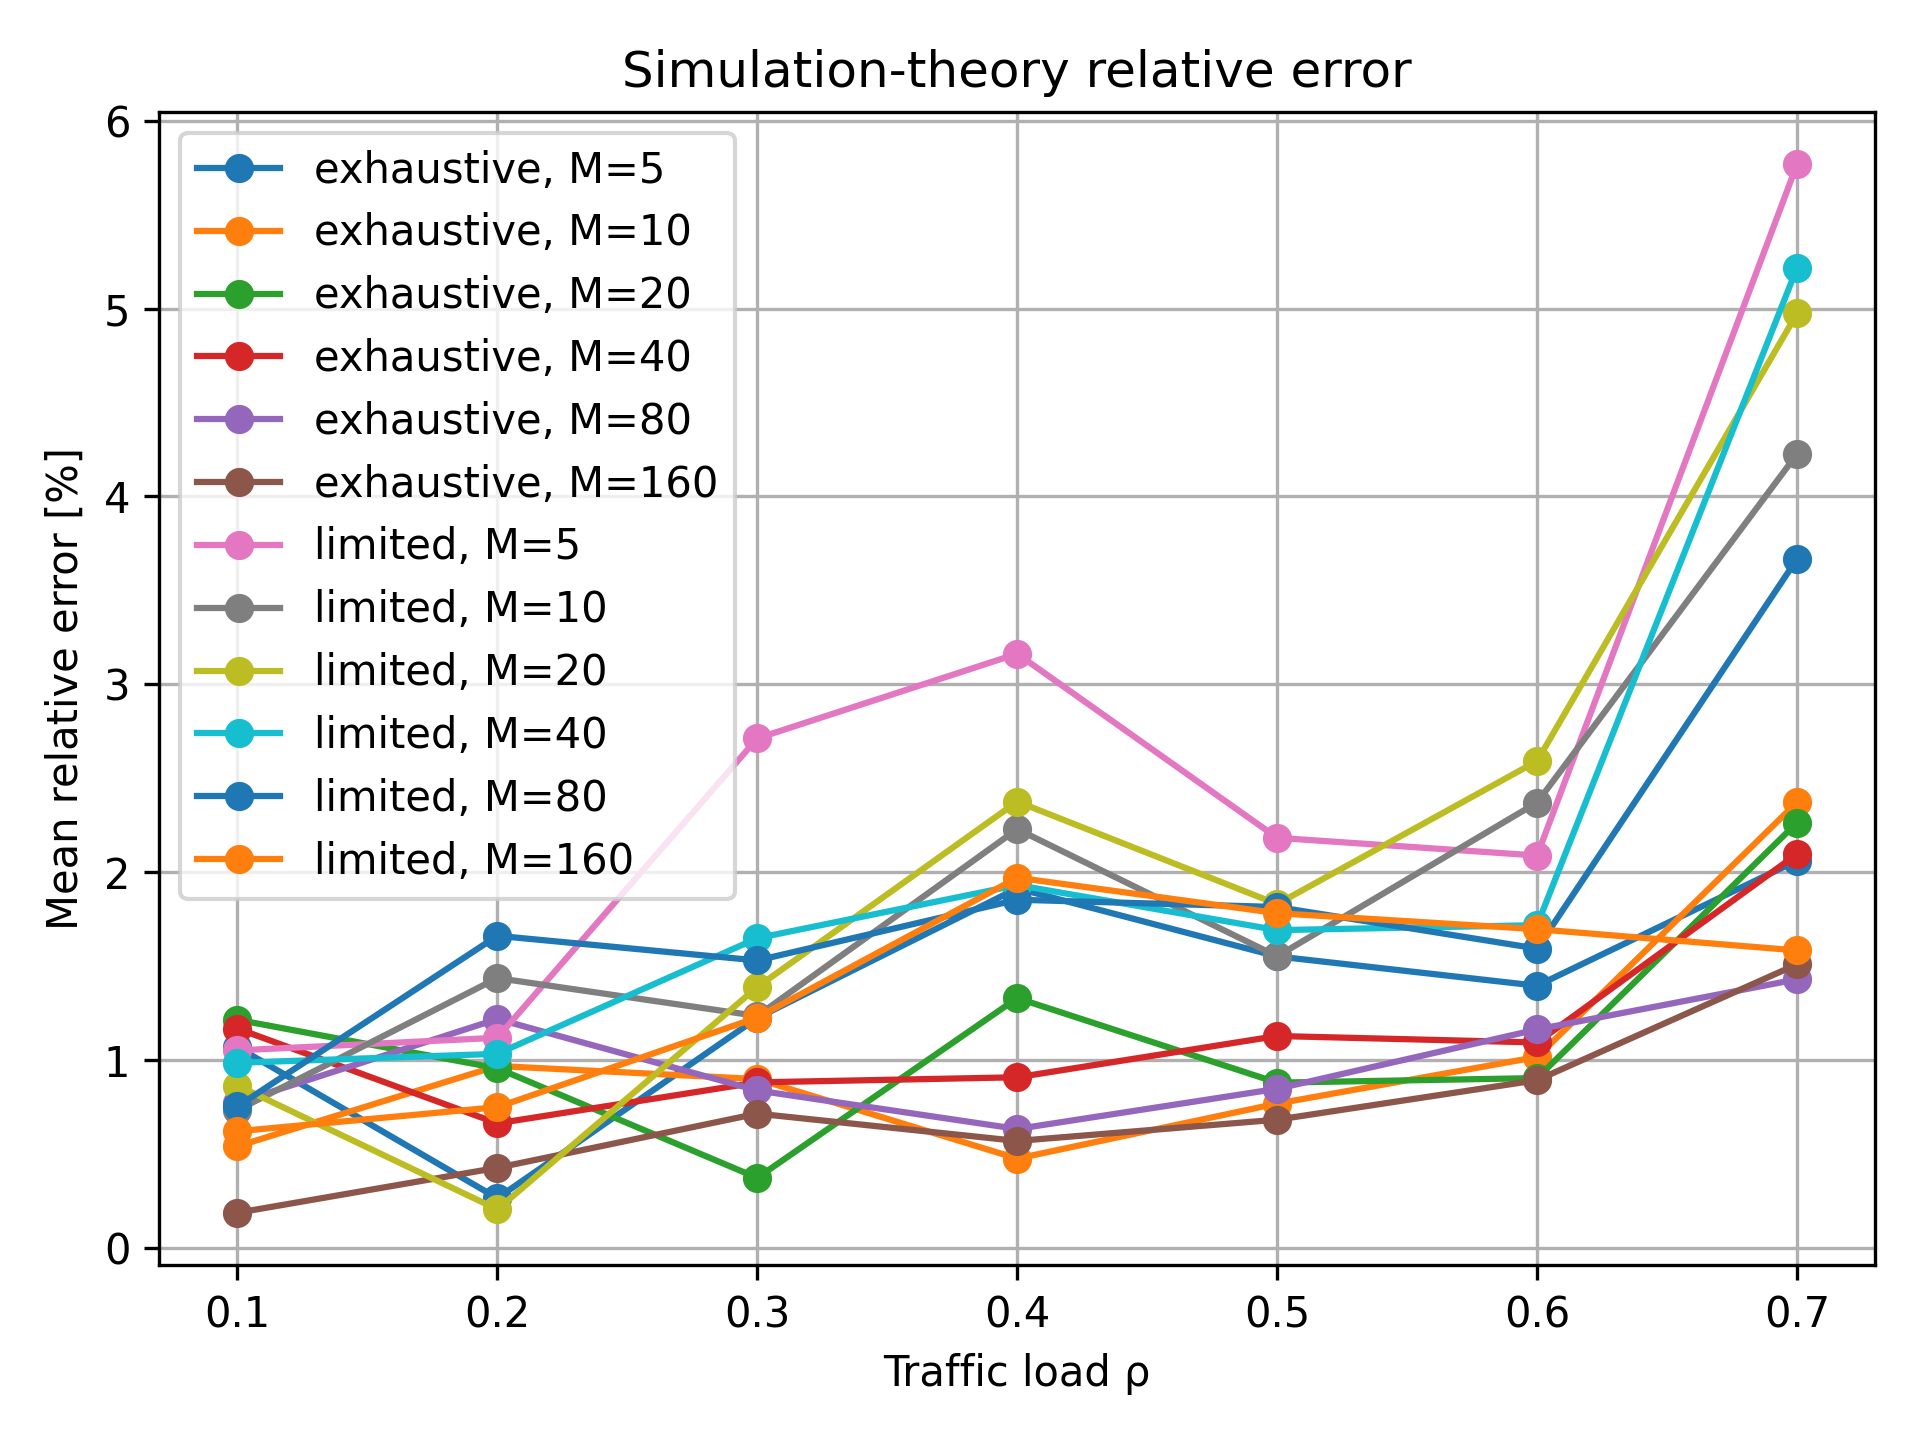

In [79]:
display_figure("relative_error_vs_rho.png", "Relative error vs traffic load")

In [80]:
relative_error_summary = (
    summary_results.groupby("discipline")
    .agg(
        mean_relative_error_percent=("mean_relative_error", lambda x: 100 * x.mean()),
        median_relative_error_percent=("mean_relative_error", lambda x: 100 * x.median()),
        max_relative_error_percent=("max_relative_error", lambda x: 100 * x.max()),
        scenarios=("rho", "size"),
    )
    .reset_index()
)

relative_error_summary

,discipline,mean_relative_error_percent,median_relative_error_percent,max_relative_error_percent,scenarios
0,exhaustive,1.0545,0.9329,5.2657,42
1,limited,1.9724,1.6945,15.0029,42


In [81]:
high_error_scenarios = (
    summary_results.assign(
        mean_relative_error_percent=100 * summary_results["mean_relative_error"],
        max_relative_error_percent=100 * summary_results["max_relative_error"],
    )
    .sort_values("max_relative_error", ascending=False)
    [[
        "discipline", "M", "rho", "T", "h", "k",
        "mean_simulation_EW", "mean_theoretical_EW",
        "mean_relative_error_percent", "max_relative_error_percent", "num_runs"
    ]]
    .head(10)
)

high_error_scenarios

,discipline,M,rho,T,h,k,mean_simulation_EW,mean_theoretical_EW,mean_relative_error_percent,max_relative_error_percent,num_runs
48,limited,5,0.7,3.0,0.8,1,30.7779,29.3824,5.7673,15.0029,3
55,limited,10,0.7,3.0,0.8,1,48.5980,47.0294,4.2258,11.3415,3
62,limited,20,0.7,3.0,0.8,1,85.4839,82.3235,4.9740,10.3727,3
69,limited,40,0.7,3.0,0.8,1,154.6806,152.9118,5.2168,8.0080,3
76,limited,80,0.7,3.0,0.8,1,300.0388,294.0882,3.6672,6.0945,3
61,limited,20,0.6,3.0,0.8,1,39.0703,38.0833,2.5916,5.2901,3
47,limited,5,0.6,3.0,0.8,1,13.3567,13.0833,2.0891,5.2832,3
13,exhaustive,10,0.7,3.0,0.8,1,16.1844,15.9000,2.3726,5.2657,3
6,exhaustive,5,0.7,3.0,0.8,1,9.4105,9.2333,2.0620,5.1446,3
44,limited,5,0.3,3.0,0.8,1,4.2576,4.1452,2.7125,5.1011,3


**Error discussion.**

The analytical model is expected to be accurate when the simulator respects the same assumptions: Poisson arrivals, deterministic service time, deterministic switching time, and stable load.

The largest errors are expected near higher loads because queues become more variable and convergence is slower. This is a simulation-variance effect, not necessarily a model failure.

## 11. Effect of the number of stations

This section studies how waiting time changes when the number of stations `M` changes.

### Waiting time vs number of stations

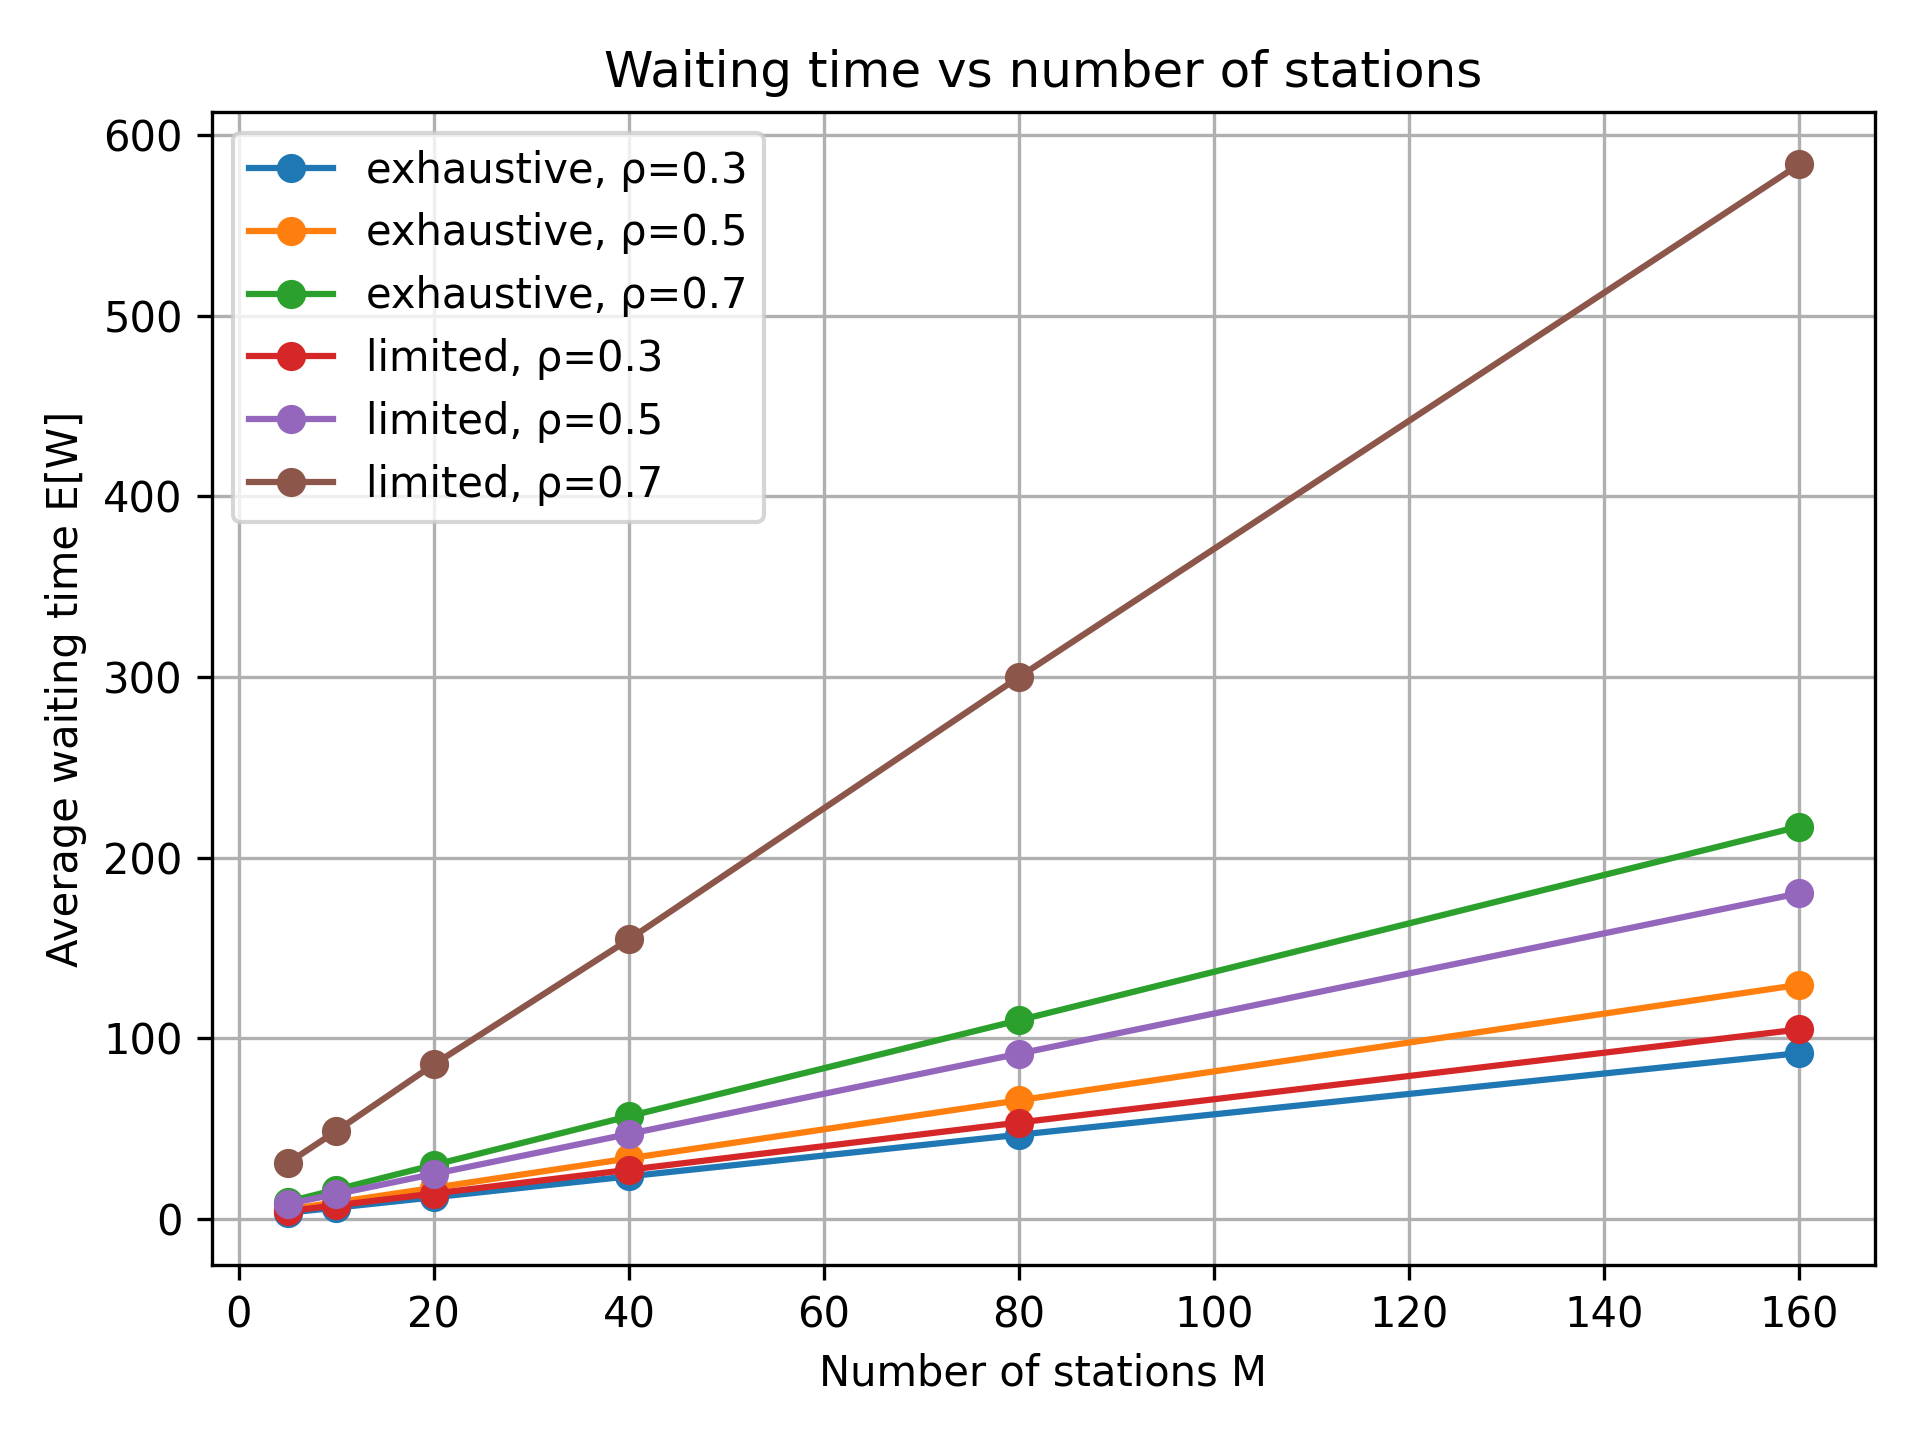

In [82]:
display_figure("waiting_time_vs_M.png", "Waiting time vs number of stations")

In [83]:
# Use rho = 0.7 if available. Otherwise use the largest common rho.
if np.isclose(summary_results["rho"], 0.7).any():
    selected_rho_for_M = 0.7
else:
    selected_rho_for_M = summary_results["rho"].max()

m_effect_table = (
    summary_results.loc[np.isclose(summary_results["rho"], selected_rho_for_M)]
    [["discipline", "M", "rho", "mean_simulation_EW", "mean_theoretical_EW", "mean_relative_error"]]
    .assign(mean_relative_error_percent=lambda x: 100 * x["mean_relative_error"])
    .sort_values(["discipline", "M"])
)

print(f"rho selected for M-effect table: {selected_rho_for_M}")
m_effect_table

rho selected for M-effect table: 0.7


,discipline,M,rho,mean_simulation_EW,mean_theoretical_EW,mean_relative_error,mean_relative_error_percent
6,exhaustive,5,0.7,9.4105,9.2333,0.0206,2.0620
13,exhaustive,10,0.7,16.1844,15.9000,0.0237,2.3726
20,exhaustive,20,0.7,29.8478,29.2333,0.0226,2.2641
27,exhaustive,40,0.7,56.8044,55.9000,0.0210,2.0970
34,exhaustive,80,0.7,109.9927,109.2333,0.0143,1.4303
41,exhaustive,160,0.7,217.2308,215.9000,0.0151,1.5100
48,limited,5,0.7,30.7779,29.3824,0.0577,5.7673
55,limited,10,0.7,48.5980,47.0294,0.0423,4.2258
62,limited,20,0.7,85.4839,82.3235,0.0497,4.9740
69,limited,40,0.7,154.6806,152.9118,0.0522,5.2168


**Number-of-stations discussion.**

For fixed traffic load, increasing `M` increases the token cycle duration and the revisit time of each station. A packet that arrives just after its station was served must wait longer before the token returns. Switching overhead also accumulates over more stations.

## 12. Exhaustive versus limited polling

This section compares the two service disciplines directly using the simulated waiting times.

In [84]:
comparison = summary_results.pivot_table(
    index=["M", "rho", "T", "h", "k"],
    columns="discipline",
    values="mean_simulation_EW",
).reset_index()

if {"exhaustive", "limited"}.issubset(comparison.columns):
    comparison["limited_over_exhaustive"] = comparison["limited"] / comparison["exhaustive"]
else:
    comparison["limited_over_exhaustive"] = np.nan

comparison.sort_values(["M", "rho"]).head(20)

discipline,M,rho,T,h,k,exhaustive,limited,limited_over_exhaustive
0,5,0.1,3.0,0.8,1,2.3262,2.4863,1.0688
1,5,0.2,3.0,0.8,1,2.7824,3.2232,1.1584
2,5,0.3,3.0,0.8,1,3.3693,4.2576,1.2636
3,5,0.4,3.0,0.8,1,4.1445,5.7716,1.3926
4,5,0.5,3.0,0.8,1,5.1792,8.2211,1.5873
5,5,0.6,3.0,0.8,1,6.7428,13.3567,1.9809
6,5,0.7,3.0,0.8,1,9.4105,30.7779,3.2706
7,10,0.1,3.0,0.8,1,4.5596,4.7733,1.0469
8,10,0.2,3.0,0.8,1,5.2522,5.8850,1.1205
9,10,0.3,3.0,0.8,1,6.1993,7.4620,1.2037


In [85]:
limited_vs_exhaustive_summary = comparison["limited_over_exhaustive"].describe().to_frame("limited_over_exhaustive_ratio")
limited_vs_exhaustive_summary

,limited_over_exhaustive_ratio
count,42.0000
mean,1.5340
std,0.6120
min,1.0298
25%,1.1261
50%,1.2695
75%,1.6981
max,3.2706


**Discipline-comparison discussion.**

Exhaustive polling is more adaptive: a busy station can transmit all queued packets during its visit. Limited polling bounds the service per visit and, with `k=1`, behaves as round-robin polling.

In the symmetric scenarios tested here, limited polling generally produces higher waiting time than exhaustive polling.

Important interpretation:

> Equal visit opportunity does not imply equal delay.

This becomes especially visible in the asymmetric hot-station extension.

## 13. Extension: hot station

The extension introduces one station with significantly higher traffic than the others.

Main objective:

- analyze waiting time per station;
- evaluate fairness across stations;
- compare exhaustive and limited polling.

In [86]:
extension_overview = (
    extension_per_station.groupby(["discipline", "station_id", "is_hot_station"])
    .agg(
        mean_waiting_time=("waiting_time", "mean"),
        std_waiting_time=("waiting_time", "std"),
        arrival_rate=("arrival_rate", "mean"),
        seeds=("seed", "nunique"),
    )
    .reset_index()
    .sort_values(["discipline", "station_id"])
)

extension_overview.head(20)

,discipline,station_id,is_hot_station,mean_waiting_time,std_waiting_time,arrival_rate,seeds
0,exhaustive,0,True,11.1169,0.1596,0.0364,3
1,exhaustive,1,False,11.8640,0.1860,0.0182,3
2,exhaustive,2,False,11.7479,0.0423,0.0182,3
3,exhaustive,3,False,11.7403,0.3003,0.0182,3
4,exhaustive,4,False,11.9353,0.2599,0.0182,3
5,exhaustive,5,False,11.7653,0.2075,0.0182,3
6,exhaustive,6,False,11.9528,0.0895,0.0182,3
7,exhaustive,7,False,11.4157,0.1506,0.0182,3
8,exhaustive,8,False,11.6243,0.2667,0.0182,3
9,exhaustive,9,False,11.8156,0.2412,0.0182,3


In [87]:
hot_info = extension_overview.loc[extension_overview["is_hot_station"] == True]
normal_info = extension_overview.loc[extension_overview["is_hot_station"] == False]

if not hot_info.empty and not normal_info.empty:
    lambda_hot = hot_info["arrival_rate"].mean()
    lambda_normal = normal_info["arrival_rate"].mean()
    estimated_hot_factor = lambda_hot / lambda_normal
    print(f"Estimated lambda_hot:    {lambda_hot:.6f}")
    print(f"Estimated lambda_normal: {lambda_normal:.6f}")
    print(f"Estimated hot factor:    {estimated_hot_factor:.3f}")
else:
    print("Could not estimate hot factor from extension_per_station.csv.")

Estimated lambda_hot:    0.036364
Estimated lambda_normal: 0.018182
Estimated hot factor:    2.000


The expected extension configuration is:

```text
M = 10
rho = 0.6
T = 3
h = 0.8
hot station = station 0
hot_factor = 2
```

So the hot station receives approximately twice the arrival rate of each normal station.

## 14. Extension plots

### Extension: per-station waiting time

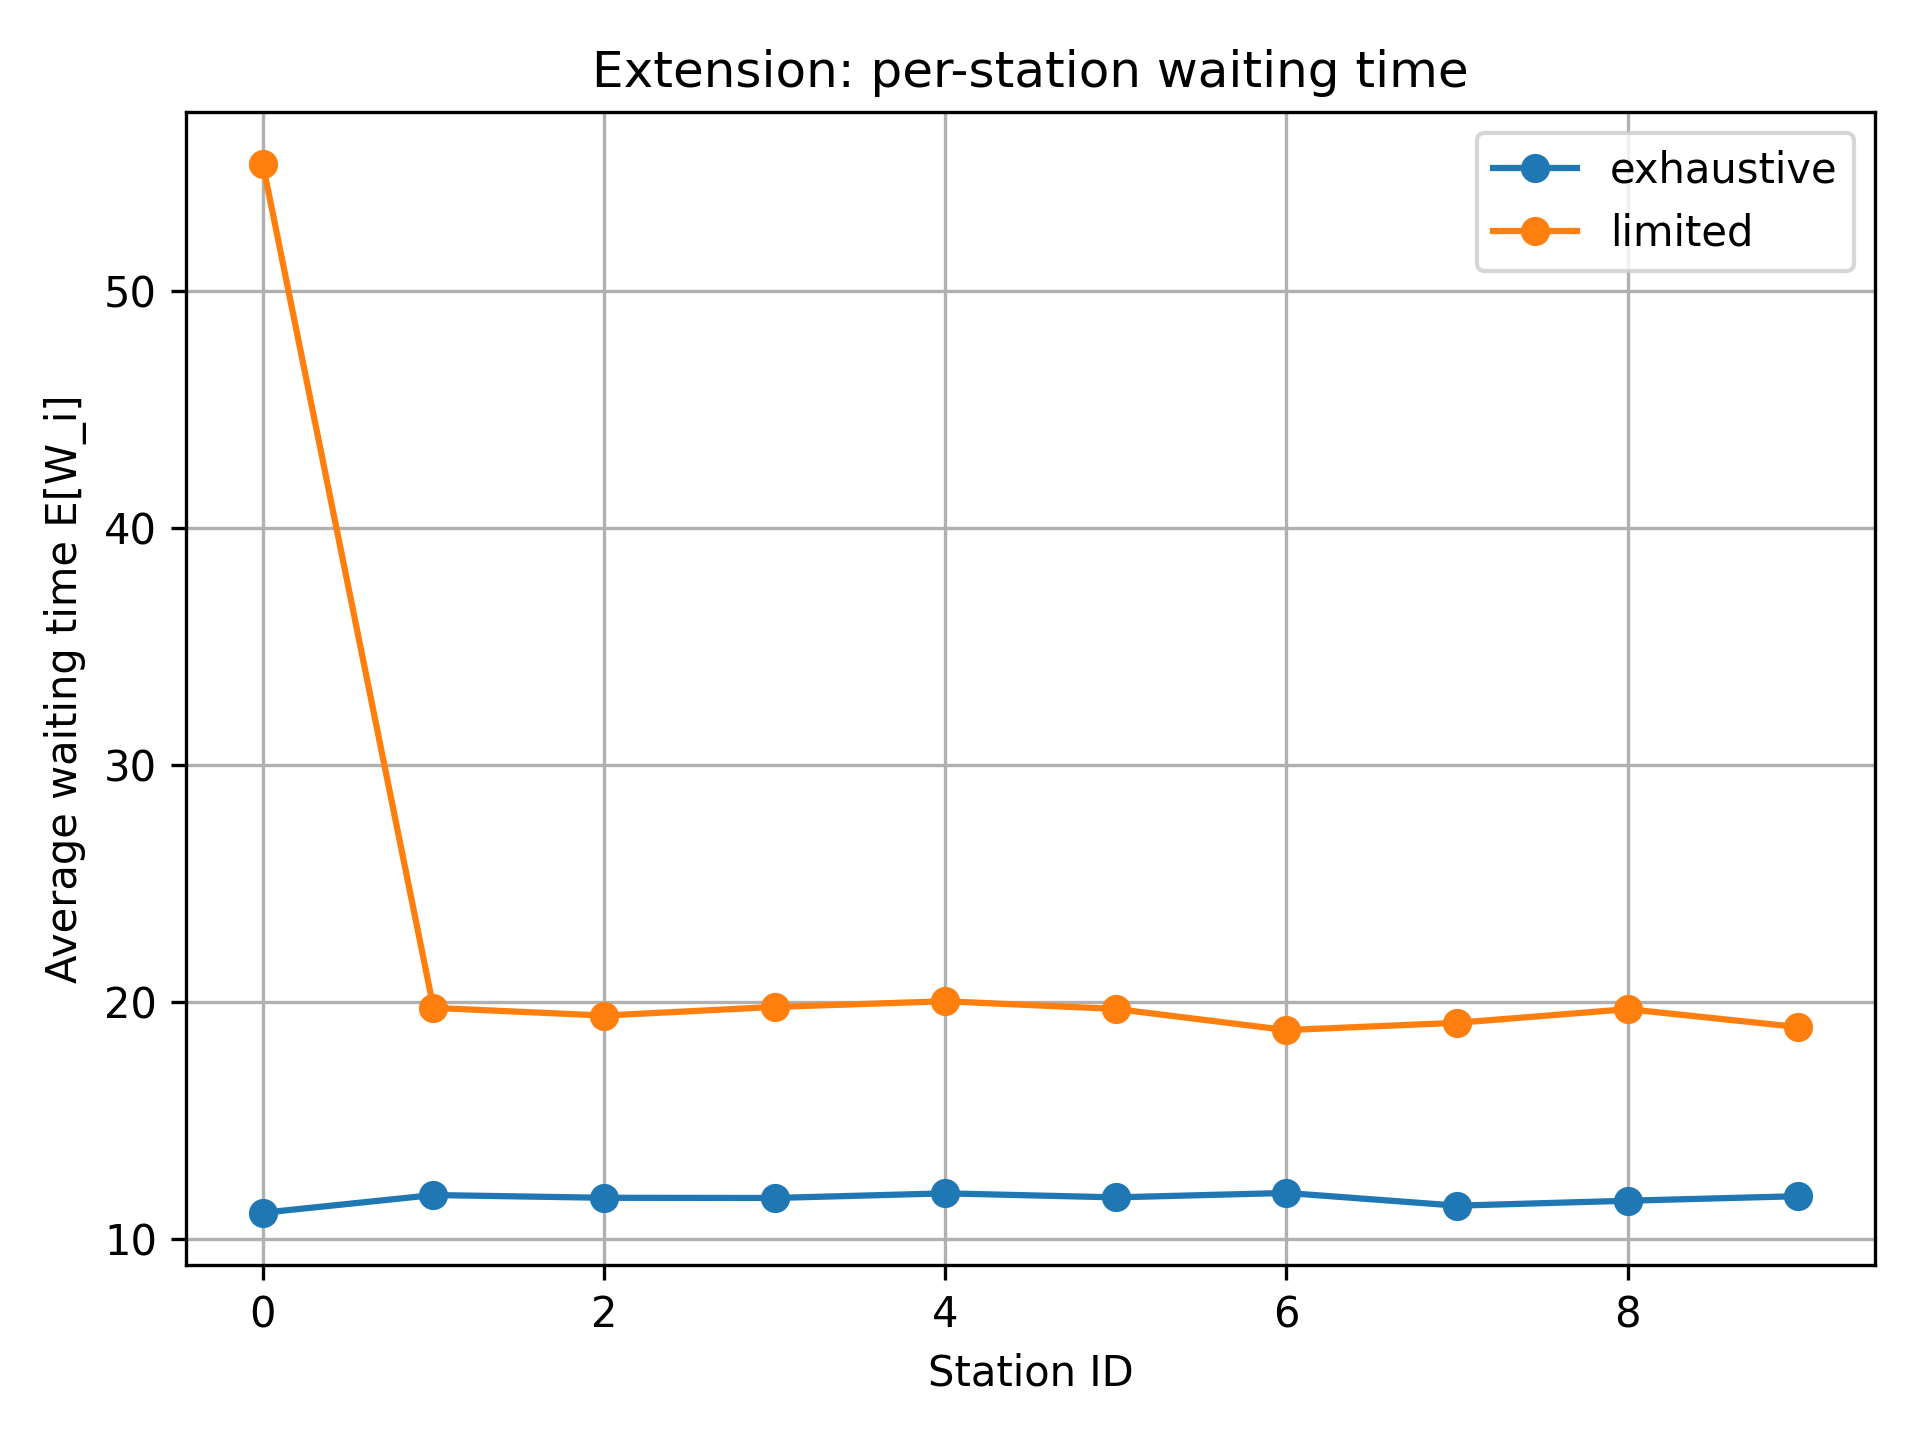

### Extension: hot station vs normal stations

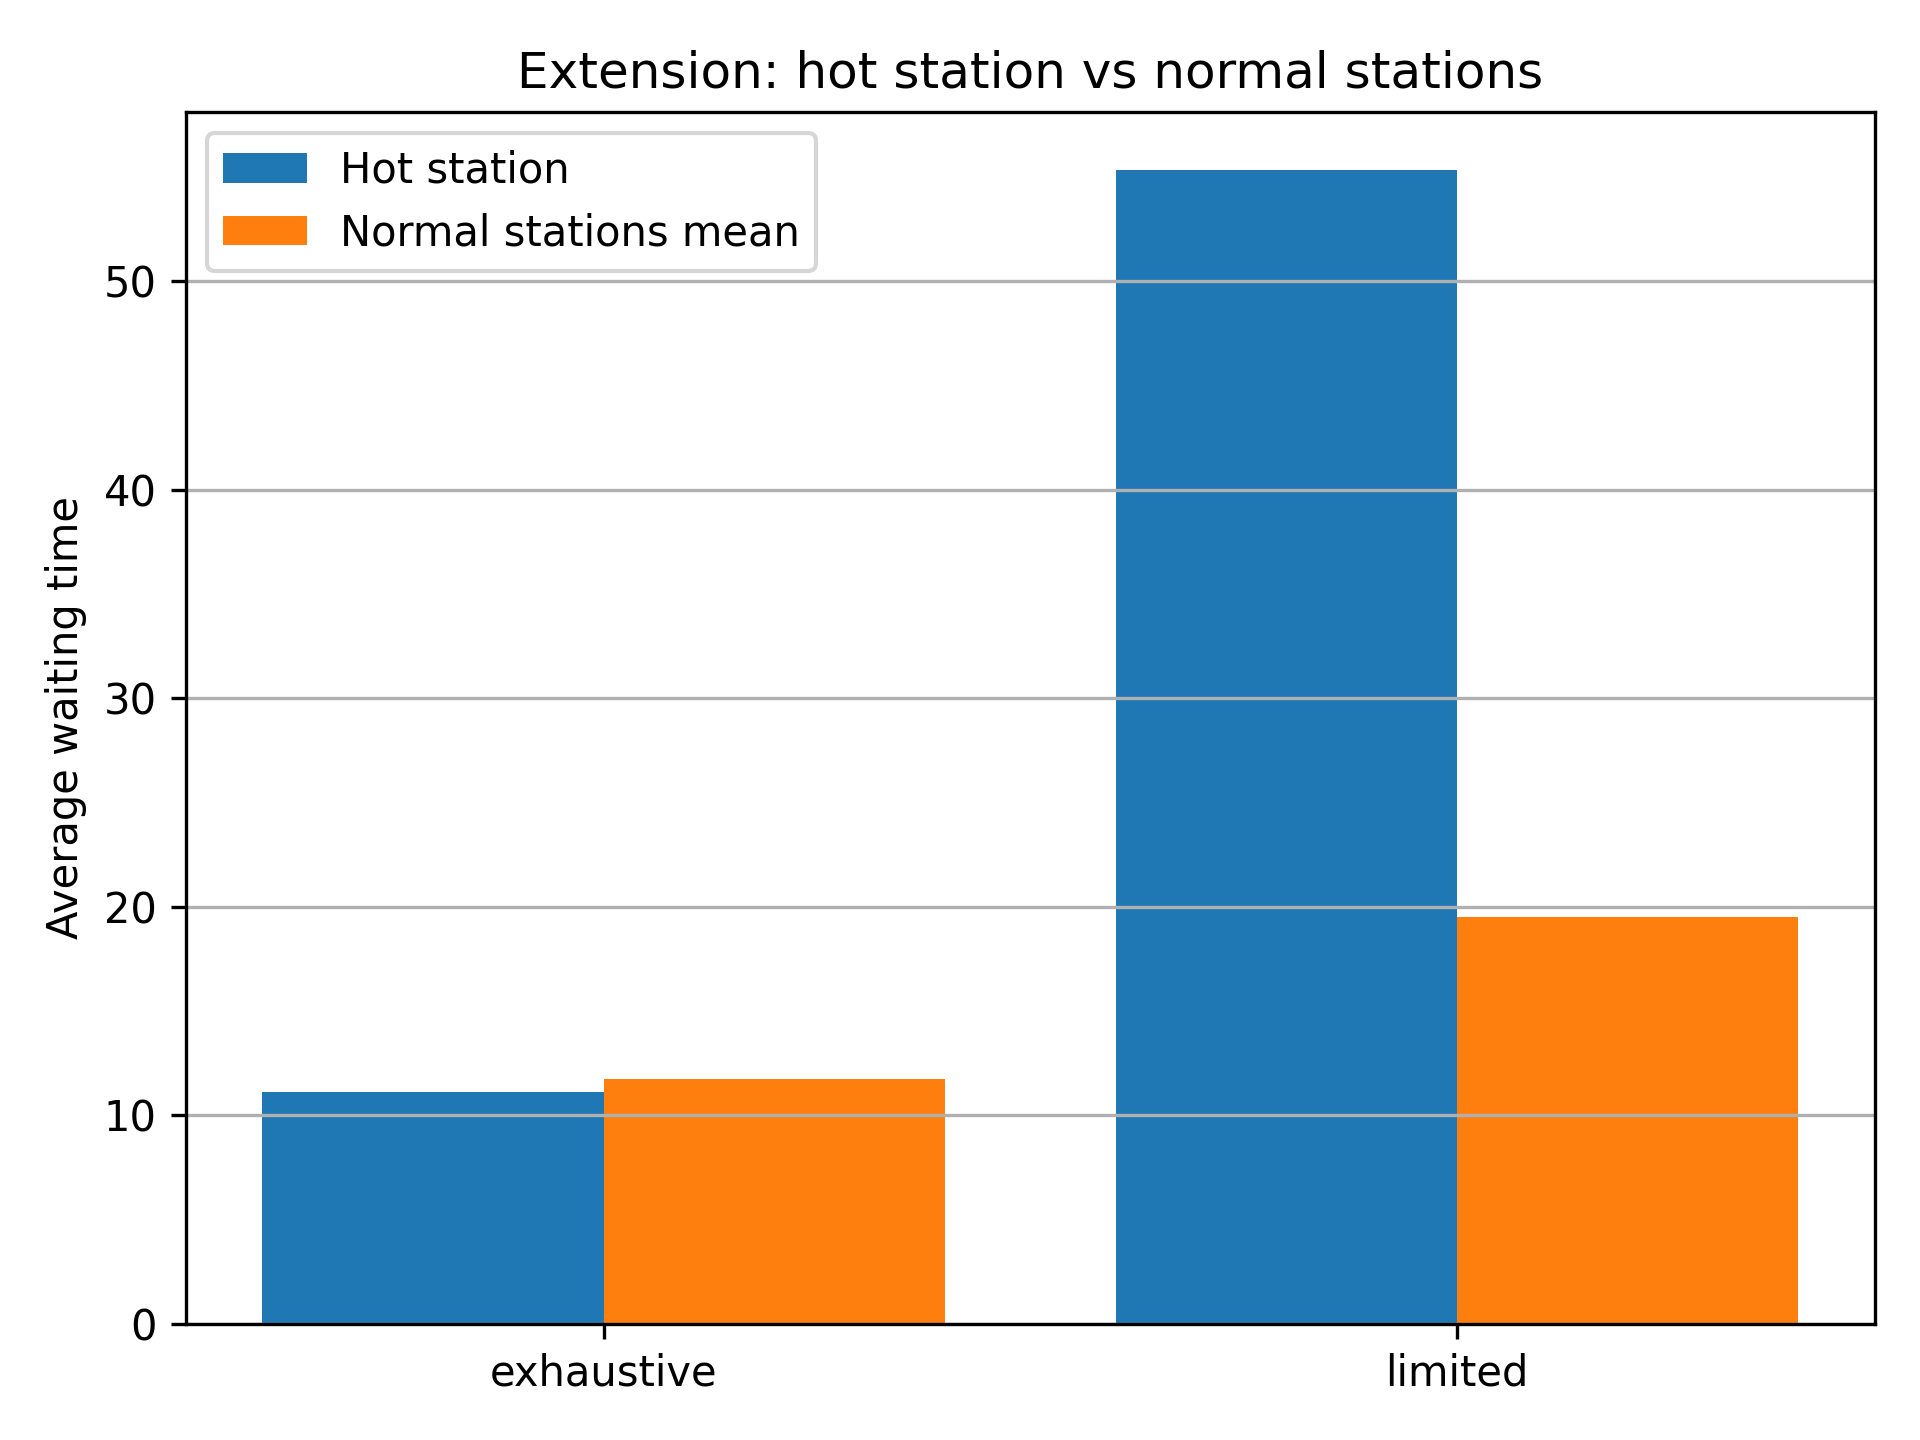

In [88]:
display_figure("extension_per_station_waiting_time.png", "Extension: per-station waiting time")
display_figure("extension_hot_vs_normal.png", "Extension: hot station vs normal stations")

**Extension discussion.**

Expected behavior:

- Under exhaustive polling, waiting times remain similar across stations because the server stays at the hot station until its queue is emptied.
- Under limited polling, the hot station is strongly penalized because only one packet can be transmitted per visit.
- The normal stations keep moderate waiting times, while the hot station accumulates backlog.

This shows that limited polling is fair in polling opportunities but not necessarily fair in experienced delay.

## 15. Fairness analysis

Fairness is evaluated from the waiting-time distribution across stations.

Metrics:

| Metric | Meaning |
|---|---|
| `hot_station_waiting_time` | Mean waiting time of the high-traffic station |
| `normal_mean_waiting_time` | Mean waiting time of the remaining stations |
| `max_min_ratio` | Ratio between maximum and minimum per-station waiting time |
| `jain_fairness_index` | Uniformity of waiting times; closer to 1 means more uniform |

In [89]:
fairness_summary = (
    extension_fairness.groupby("discipline")
    .agg(
        hot_station_waiting_time=("hot_station_waiting_time", "mean"),
        normal_mean_waiting_time=("normal_mean_waiting_time", "mean"),
        max_min_ratio=("max_min_ratio", "mean"),
        jain_fairness_index=("jain_fairness_index", "mean"),
        seeds=("seed", "nunique"),
    )
    .reset_index()
)

fairness_summary

,discipline,hot_station_waiting_time,normal_mean_waiting_time,max_min_ratio,jain_fairness_index,seeds
0,exhaustive,11.1169,11.7624,1.0860,0.9994,3
1,limited,55.3352,19.4829,3.0255,0.8208,3


In [90]:
station_waiting_summary = (
    extension_per_station.groupby(["discipline", "station_id", "is_hot_station"])
    .agg(mean_waiting_time=("waiting_time", "mean"))
    .reset_index()
    .sort_values(["discipline", "station_id"])
)

station_waiting_summary

,discipline,station_id,is_hot_station,mean_waiting_time
0,exhaustive,0,True,11.1169
1,exhaustive,1,False,11.8640
2,exhaustive,2,False,11.7479
3,exhaustive,3,False,11.7403
4,exhaustive,4,False,11.9353
5,exhaustive,5,False,11.7653
6,exhaustive,6,False,11.9528
7,exhaustive,7,False,11.4157
8,exhaustive,8,False,11.6243
9,exhaustive,9,False,11.8156


**Fairness discussion.**

A lower `max_min_ratio` means that station delays are more balanced. A Jain fairness index closer to one means that the waiting-time distribution is more uniform across stations.

The expected conclusion is:

- Exhaustive polling is fairer in delay under the tested asymmetric traffic.
- Limited polling is fair in visit opportunity but unfair in experienced waiting time.

## 16. Model validity and limitations

### When the analytical model is expected to work

The theoretical model is expected to predict the simulator well when:

- arrivals are Poisson;
- packet service time `T` is deterministic;
- switching/token time `h` is deterministic;
- the system is stable;
- simulation time is sufficiently long;
- the warm-up period is discarded.

### Limitations

The model and simulator abstract from several real wireless effects:

- finite simulation length creates statistical error;
- random seeds introduce variability;
- convergence is slower near saturation;
- no packet errors are modeled;
- no retransmissions are modeled;
- no collisions are modeled;
- no variable packet lengths are modeled;
- no PHY-rate adaptation is modeled;
- no CSMA/CA backoff is modeled.

This is acceptable because Project 3 is focused on polling-system validation, not on full 802.11 DCF emulation.

## 17. Report-ready tables

This section exports compact tables that can be directly used in the final 3-page report.

In [91]:
report_baseline = baseline_table[[
    "discipline",
    "M",
    "rho",
    "mean_simulation_EW",
    "mean_theoretical_EW",
    "mean_absolute_error",
    "mean_relative_error_percent",
    "num_runs",
]].copy()

report_error = relative_error_summary.copy()
report_fairness = fairness_summary.copy()

report_baseline.to_csv(REPORT_READY_DIR / "report_baseline_validation.csv", index=False)
report_error.to_csv(REPORT_READY_DIR / "report_relative_error_summary.csv", index=False)
report_fairness.to_csv(REPORT_READY_DIR / "report_extension_fairness_summary.csv", index=False)

print("Saved report-ready tables:")
print(REPORT_READY_DIR / "report_baseline_validation.csv")
print(REPORT_READY_DIR / "report_relative_error_summary.csv")
print(REPORT_READY_DIR / "report_extension_fairness_summary.csv")

Saved report-ready tables:
/home/garmar/wireless_project/project3-polling-systems/outputs/tables/report_ready/report_baseline_validation.csv
/home/garmar/wireless_project/project3-polling-systems/outputs/tables/report_ready/report_relative_error_summary.csv
/home/garmar/wireless_project/project3-polling-systems/outputs/tables/report_ready/report_extension_fairness_summary.csv


In [92]:
display(Markdown("## Baseline validation"))
display(report_baseline)

display(Markdown("## Relative error summary"))
display(report_error)

display(Markdown("## Extension fairness summary"))
display(report_fairness)

## Baseline validation

,discipline,M,rho,mean_simulation_EW,mean_theoretical_EW,mean_absolute_error,mean_relative_error_percent,num_runs
13,exhaustive,10,0.7,16.1844,15.9000,0.3772,2.3726,3
55,limited,10,0.7,48.5980,47.0294,1.9874,4.2258,3


## Relative error summary

,discipline,mean_relative_error_percent,median_relative_error_percent,max_relative_error_percent,scenarios
0,exhaustive,1.0545,0.9329,5.2657,42
1,limited,1.9724,1.6945,15.0029,42


## Extension fairness summary

,discipline,hot_station_waiting_time,normal_mean_waiting_time,max_min_ratio,jain_fairness_index,seeds
0,exhaustive,11.1169,11.7624,1.0860,0.9994,3
1,limited,55.3352,19.4829,3.0255,0.8208,3


## 18. Report discussion checklist

Use the following points in the final report.

### Methodology

- A discrete-event simulation was implemented in Python using SimPy.
- The system contains multiple local station queues and one cyclic polling server.
- Packet arrivals are Poisson.
- The simulator supports exhaustive and limited polling.
- The main metric is packet waiting time.

### Validation

- Simulation results were compared with theoretical formulas from the course.
- Both exhaustive and limited polling were tested.
- Relative error remained small over the tested operating range.
- Higher error at high load is expected because queueing systems converge more slowly near saturation.

### Parameter sensitivity

- Increasing `rho` increases waiting time.
- Increasing `M` increases waiting time because the polling cycle becomes longer.
- Limited polling produces larger waiting time than exhaustive polling under symmetric traffic.

### Extension

- One station was configured with higher traffic.
- Exhaustive polling adapted to the hot station.
- Limited polling penalized the hot station because service per visit is capped.
- Delay fairness is better under exhaustive polling for this asymmetric scenario.

## 19. Final conclusions

1. The simulator validates the theoretical waiting-time models with small relative error.

2. Waiting time increases with traffic load `rho`.

3. Waiting time increases with the number of stations `M` because polling cycles become longer.

4. Exhaustive polling generally produces lower waiting time than limited polling in the tested symmetric scenarios.

5. Under asymmetric traffic, exhaustive polling adapts better to the hot station.

6. Limited polling strongly penalizes high-traffic stations because service per visit is capped.

7. The analytical model is reliable when the simulation assumptions match the theoretical assumptions.

## 20. Notebook output summary

After running this notebook, the report-ready tables are available in:

```text
outputs/tables/report_ready/
```

The figures used in the report are available in:

```text
outputs/figures/
```

Recommended report figures:

```text
waiting_time_vs_rho_exhaustive.png
waiting_time_vs_rho_limited.png
relative_error_vs_rho.png
waiting_time_vs_M.png
extension_hot_vs_normal.png
```

Optional additional figure:

```text
extension_per_station_waiting_time.png
```